# LMECA2300: Advanced Numerical Methods
## Assignment 6

**Students:**
- Student 1: Victor Lepère (61502000)
- Student 2: Max Opdecam(77062000)

### Full multipole code

Given the increasing importance of social media in our digital society, the number of content creators has proliferated. To produce engaging videos that appeal to a wide audience, high-quality audio and video have become essential in content creation. While expensive devices can reliably deliver high-quality images regardless of the context, improving audio quality is often trickier. Not only must the recording device be sufficiently capable, but careful attention must also be paid to the acoustic resonance of the recording room.

To reduce echoes and reverberation, content creators commonly cover their walls with acoustic foam. These foams typically have wedged or pyramidal shapes to enhance the diffusion of sound waves. In this homework, we aim to gain deeper insight into the effectiveness of these designs by simulating the interaction between incoming acoustic waves and a wedge-shaped model of such foam.

eft Non

In [210]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as manim
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg') 
from scipy.special import hankel2

### Physical constants
rho0 = 1.2 # air, 20°C, 1 atm
f = 1000 # [hz]
w = 2*np.pi*f # air -> 343 = w/k
k = w/343
lambda_ = (2*np.pi)/k

In [211]:
class Segment:

    def __init__(self, r1, r2):
        self.r1 = np.asarray(r1)
        self.r2 = np.asarray(r2)
        self.Vn = 1

    def set_Vn(self, Vn):
        self.Vn = Vn

    def __str__(self):
        return f"({self.r1[0]:.2f}, {self.r1[1]:.2f}) ---- ({self.r2[0]:.2f}, {self.r2[1]:.2f})"

    def length(self):
        return np.linalg.norm(self.r2 - self.r1)

    def __translation_func(self, beta):
        R0 = np.linalg.norm(self.obs)
        phi0 = np.arctan2(self.obs[1], self.obs[0]) % (2 * np.pi) # the angles ranges from 0 to 2pi, as for beta rather than -pi, pi 

        l_values = np.arange(self.L + 1)
        c_values = np.where(l_values > 0, 2 * (-1j) ** l_values, 1)
        H2_values = hankel2(l_values, k*R0)

        result = c_values * np.cos(l_values[np.newaxis, :] * (beta[:, np.newaxis] - phi0)) * H2_values
        
        assert result.shape == (len(beta), self.L+1)

        return np.sum(result, axis=1)

    def __F(self, u_beta):
        p_half = k*(u_beta@(self.r2 - self.r1))/2
        return np.exp(1j*k*u_beta@self.r1) * self.length() * np.exp(1j*p_half) * np.sinc(p_half / np.pi)
    
    def __integrate_hankel(self, a, b, m, case):
        """
        Aux. function that integrates Hankel function from a to b via singularity extraction

        @param a: lower intergration bound
        @param b: upper integration bound
        @param case: symmetric/general case
        @param m: number of integration points
        """
        s = np.linspace(a, b, m)
        if case == 1:
            diff = s[:, np.newaxis] * (self.r2 - self.obs)
        else:
            diff = self.obs - (self.r1 + s[:, np.newaxis] * (self.r2 - self.r1))
        rho = np.linalg.norm(diff, axis=1)
        singularity_mask = k*rho <= lambda_/1000

        evals = np.zeros_like(rho, dtype=np.complex128)
        cst = 1 - 1j*(2/np.pi)*(np.euler_gamma - np.log(2))
        evals[singularity_mask] = cst
        subset_rho = rho[~singularity_mask]
        evals[~singularity_mask] = hankel2(0, k*subset_rho) + 1j*(2/np.pi)*np.log(k*subset_rho)

        h = (b - a) / m

        evals[0] *= 1/2
        evals[-1] *= 1/2
        first_term = h*np.sum(evals)
        if case == 1:
            if a == 0:
                last = 0
            else:
                last = a*(np.log(a)-1)
            second_term = -1j*(2/np.pi)*((b-a)*(np.log(k)+np.log(np.linalg.norm(self.r2-self.obs))) + (b*(np.log(b)-1) - last))
        else:
            pass

        return first_term + second_term
    
    def sym_radiated_field(self, mid, m=40):
        """
        Integrates complex amplitude for an obsever point ON the segment (MIDPOINT), and thus takes advantage of symmetry.

        @param mid: coord. of midpoint
        """        
        s = np.linspace(0, 1, m)
        diff = s[:, np.newaxis] * (self.r2 - mid)
        rho = np.linalg.norm(diff, axis=1)
        singularity_mask = k*rho <= lambda_/1000

        evals = np.zeros_like(rho, dtype=np.complex128)
        j2pi = 1j*(2/np.pi)
        cst = 1 - j2pi*(np.euler_gamma - np.log(2))
        evals[singularity_mask] = cst
        subset_rho = rho[~singularity_mask]
        evals[~singularity_mask] = hankel2(0, k*subset_rho) + j2pi*np.log(k*subset_rho)
        evals[0] *= .5; evals[-1] *= .5
        
        first_term = np.sum(evals)/m
        second_term = -j2pi * (np.log(k) + np.log(self.length()) - np.log(2) - 1)

        return self.Vn * w * rho0 * self.length() * (first_term + second_term) / 4.
    
    def conv_radiated_field(self, grid_domain, m=2000):
        """
        Radiation integral computation from HW2 using convolution
        """
        grid_domain = np.atleast_2d(grid_domain) # (N,2)

        s = np.linspace(0, 1, m) # (m,)
        diff = grid_domain[:, np.newaxis, :] - (self.r1 + s[:, np.newaxis] * (self.r2-self.r1)) # (N,m,2)
        rho = np.linalg.norm(diff, axis=-1) # (N,m)

        H = hankel2(0, k * rho) # (N,m)
        if np.any(np.isnan(H)):
            raise ValueError("Hankel function evaluated at singular point, change geometry or grid.")
        
        H[:, 0] *= 1/2
        H[:, -1] *= 1/2

        integral = self.Vn * w * rho0 * self.length() * np.sum(H, axis=1) / (4*m) # (N,)
        return integral


    def radiated_field(self, obs, grid_domain, m=50, L=35):
        """
        Integrates radiation integral for grid_domain with center obs

        @param obs: coord of center of observation domain
        @param grid_domain: coords of grid nodes where to compute pressure around the center
        @param m: number of integration nodes used for beta discretization
        @param L + 1: number of terms of truncated Fourier series of Hankel function
        """
        self.obs = np.asarray(obs)
        grid_domain = np.asarray(grid_domain)
        self.L = L

        betas = (2*np.pi/m) * np.arange(m + 1)
        u_betas = np.hstack([np.cos(betas)[:, np.newaxis], np.sin(betas)[:, np.newaxis]])
        
        assert u_betas.shape == (m+1,2)

        radiation_patterns = self.__F(u_betas)
        planar_waves = np.exp(-1j * k * u_betas @ (grid_domain - self.obs[np.newaxis, :]).T)
        trans_funcs = self.__translation_func(betas)

        assert radiation_patterns.shape == (m+1,), radiation_patterns.shape
        assert planar_waves.shape == (m+1, len(grid_domain)), planar_waves.shape
        assert trans_funcs.shape == (m+1,), trans_funcs.shape

        integral = radiation_patterns[:, np.newaxis] * planar_waves * trans_funcs[:, np.newaxis]
        integral[0, :] *= 0.5
        integral[m, :] *= 0.5

        return w * rho0 * self.Vn * np.sum(integral, axis=0) / (4*m)

You can find below a small function that generates a wedge-shaped foam given a number $N$ of wedges and a wedge angle $\phi$.

Circle needed 5 segments to generate.
Circle needed 5 segments to generate.
Circle needed 5 segments to generate.
Circle needed 5 segments to generate.
Circle needed 5 segments to generate.
Circle needed 5 segments to generate.
Circle needed 5 segments to generate.
Circle needed 5 segments to generate.
Circle needed 5 segments to generate.
Circle needed 5 segments to generate.
Circle needed 5 segments to generate.
Circle needed 5 segments to generate.
Circle needed 5 segments to generate.
Circle needed 5 segments to generate.
Circle needed 5 segments to generate.
Circle needed 5 segments to generate.


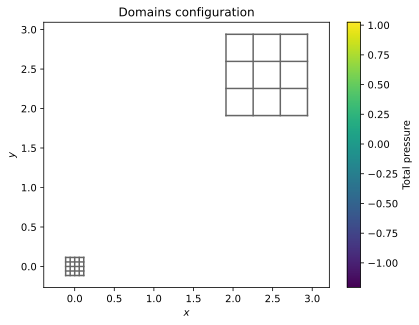

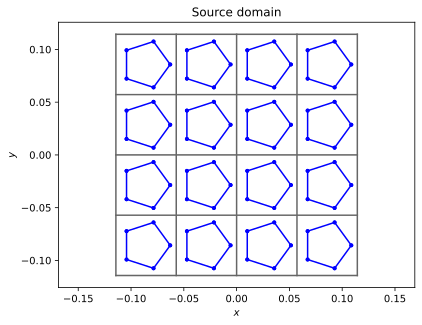

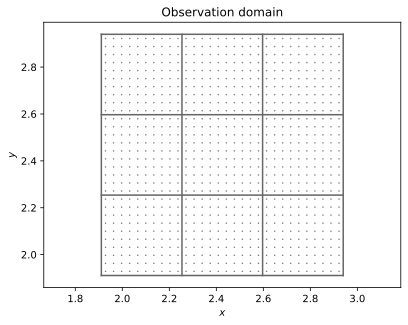

In [212]:
# another geometry
def generate_circle(center, radius, length=lambda_/10):
    """
    Parameters
    ----------
    rayon : int
        rayon en cellule.
    center : (int,int)
        index matrice du centre.
    Returns
    -------
    liste des edges du pourtour de la section.
    """
    
    circonf = 2*np.pi*radius
    n_edges = int(np.ceil(circonf/length))
    print(f"Circle needed {n_edges} segments to generate.")
    
    angle = 360/n_edges/180*np.pi
    r1 = np.array(center)+np.array((radius,0))
    all_edges = []
    current_angle = angle
    
    #création des edges
    for i in range(n_edges):
        r2 = center + np.array((radius*np.cos(current_angle), radius*np.sin(current_angle)))
        edge = Segment(r1, r2)
        all_edges.append(edge)
        r1 = r2
        current_angle = current_angle + angle

    return all_edges

class Boxes:
    """
    Grid of boxes
    """
    def __init__(self, center, gridsize, n_boxes):
        """
        @param center: center of grid in global coordinates
        @param gridsize: length of side's square boxes
        @param n_boxes: number of boxes along each dimension
        """
        self.center = np.asarray(center)
        self.gridsize = gridsize
        self.n_boxes = n_boxes

        self.__create_axes()

    def __create_axes(self):
        """
        Creates list of origin coordinates corresponding to each local axes of boxes
        """
        self.axes = []
        self.__bottom_left = self.center - (self.n_boxes/2.) * self.gridsize
        for i in range(self.n_boxes):
            for j in range(self.n_boxes):
                self.axes.append(
                    self.__bottom_left + np.ones(2) * (self.gridsize/2.) + np.array([i*self.gridsize, j*self.gridsize])
                )
    
    def get_origin(self, i, j):
        return self.axes[(self.n_boxes-1-i)*self.n_boxes + j]

    def plot(self):
        for i in range(self.n_boxes+1):
            plt.plot(
                [self.__bottom_left[0], self.__bottom_left[0] + self.n_boxes*self.gridsize],
                [self.__bottom_left[1]+i*self.gridsize] * 2,
                color = "0.4"
            )
            plt.plot(
                [self.__bottom_left[0]+i*self.gridsize] * 2,
                [self.__bottom_left[1], self.__bottom_left[1] + self.n_boxes*self.gridsize],
                color = "0.4"
           )
            
class SourceDomain(Boxes):
    def __init__(self, center, gridsize, n_boxes):
        super().__init__(center, gridsize, n_boxes)

    def get_F(self, i, j, shape):
        """
        Returns radiation patterns from box (i, j) containing segments of shape
        """
        def F(beta):
            itg = 0.
            u_beta = np.array([np.cos(beta), np.sin(beta)])
            local_origin = self.get_origin(i,j)
            for s in shape:
                r2 = s.r2 - local_origin
                r1 = s.r1 - local_origin

                p_half = k*(u_beta@(r2 - r1))/2
                itg += s.Vn * np.exp(1j*k*u_beta@r1) * s.length() * np.exp(1j*p_half) * np.sinc(p_half / np.pi)
            return itg
        return F
        
class ObsDomain(Boxes):
    def __init__(self, center, gridsize, n_boxes):
        super().__init__(center, gridsize, n_boxes)

    def get_T(self, source_origin, i, j):
        """
        Returns translation function between source and box (i, j) of observation grid
        """
        def T(beta, L):
            local_origin = self.get_origin(i, j)
            R0 = np.linalg.norm(source_origin - local_origin)
            phi0 = np.arctan2(local_origin[1], local_origin[0]) % (2 * np.pi) # the angles ranges from 0 to 2pi, as for beta rather than -pi, pi 

            l_values = np.arange(L + 1)
            c_values = np.where(l_values > 0, 2 * (-1j) ** l_values, 1)
            assert c_values[0] == 1
            H2_values = hankel2(l_values, k*R0)
            result = c_values * np.cos(l_values * (beta - phi0)) * H2_values
        
            return np.sum(result)

def generate_mesh(domain, points_per_box):
    """
    Generates a mesh centered on the observation domain with points_per_box along each dimensions in each box.
    ! Assumes center of obs domain has positive coordinates !
    """
    shift = (domain.n_boxes/2.) * domain.gridsize
    left = domain.center[0] - shift
    right = domain.center[1] + shift

    m = points_per_box * domain.n_boxes
    offset = (right - left) / (2*(m-1))
    x = np.linspace(left+offset, right-offset, m)
    X, Y = np.meshgrid(x,x)

    return np.column_stack((X.ravel(), Y.ravel()))

src_by_side = 4
obs_by_side  =3

### source domain
source_grid = SourceDomain([0, 0], lambda_/6, src_by_side)

### observation domain
obs_grid = ObsDomain([np.sqrt(2)*5*lambda_]*2, lambda_, 3)

### shapes
groups = []
for i in range(src_by_side):
    row = []
    for j in range(src_by_side):
        source_grid.get_origin(i, j)
        row.append(
            generate_circle(source_grid.get_origin(i,j), lambda_/15, length=lambda_/10)
        )
    groups.append(row)
groups = np.array(groups)

### show geometry
plt.cla()
plt.title("Domains configuration")
source_grid.plot()
obs_grid.plot()
plt.axis("equal")
plt.xlabel("$x$"); plt.ylabel("$y$")
plt.show()

plt.title("Source domain")
for row in groups:
    for g in row:
        for s in g:
            plt.plot([s.r1[0], s.r2[0]], [s.r1[1], s.r2[1]], "b.-")
source_grid.plot()
plt.axis("equal")
plt.xlabel("$x$"); plt.ylabel("$y$")
plt.show()

plt.title("Observation domain")
obs_grid.plot()
mesh_points = 10
mesh = generate_mesh(obs_grid, mesh_points)
plt.scatter(mesh[:, 0], mesh[:, 1], c='gray', marker='+', s=.75)
plt.axis("equal")
plt.xlabel("$x$"); plt.ylabel("$y$")
plt.show()

(0.7381444851051177+0.6746426603090712j)
[-0.67470693-0.60247098j]
[0.06343756]


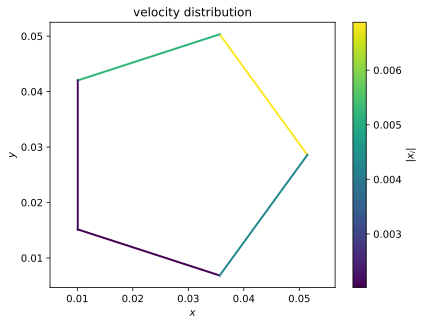

In [213]:
def build_system(shape, p_inc):
    """
    build linear system Ax = b as described above

    @param shape: a collection of Edge's
    @param p_inc: function that yields the complex amplitude of the incident field
    """
    N = len(shape)
    A = np.zeros((N, N), dtype=complex)
    b = np.zeros(N, dtype=complex)

    for i in range(N):
        edge = shape[i]
        midpoint = 0.5 * (edge.r1 + edge.r2)
        for j in range(N):
            edge = shape[j]
            if i == j:
                A[i,j] = edge.sym_radiated_field(midpoint)
            else:
                A[i,j] = edge.conv_radiated_field(midpoint, m=100)[0]
        b[i] = -p_inc(midpoint)

    return A,b 

### incident field    
P0 = 1
u = [np.sqrt(2)/2, np.sqrt(2)/2]
p_inc = lambda r : P0 * np.exp(1j * k * (np.asarray(r) @ np.asarray(u)))

### compute normal velocities for each shape
for _ in groups:
    for shape in _:
        A, b = build_system(shape, p_inc)
        xi = np.linalg.solve(A,b)

        # set solution for each segment
        for i in range(len(xi)):
            shape[i].set_Vn(xi[i])

shape = groups[1][2]
rad_field = 0.0
obs = source_grid.get_origin(1, 2)

for s in shape:
    #print(s.r1, s.r2)
    rad_field += s.conv_radiated_field(obs, m=10)

plt.show()
print(p_inc(obs))
print(rad_field)
tot = rad_field + p_inc(obs)
print(np.real(tot * np.exp(1j*w*1)))


xi_abs = np.abs([s.Vn for s in groups[1][2]])
norm = mcolors.Normalize(vmin=np.min(xi_abs), vmax=np.max(xi_abs))  
cmap = cm.viridis  # Choose a colormap

### Plot
plt.figure(dpi=150)
for i in range(len(shape)):
    color = cmap(norm(xi_abs[i]))  
    plt.plot([shape[i].r1[0], shape[i].r2[0]], [shape[i].r1[1], shape[i].r2[1]], "-", color=color, linewidth=2)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, label=r"$|x_i|$",ax=plt.gca())
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.axis('equal')
plt.title("velocity distribution")
plt.show()

gridsize = 50
x = np.linspace(-0.09, 0.15, gridsize)
X, Y = np.meshgrid(x, x)
coord_array = np.column_stack((X.ravel(), Y.ravel()))

# Radiated field computation
grid_radiated = np.zeros((gridsize * gridsize, len(shape)), dtype=complex)
for i in range(len(shape)):
    grid_radiated[:, i] = shape[i].conv_radiated_field(coord_array, m=100)

grid_radiated = np.sum(grid_radiated, axis=-1)
grid_incident = p_inc(coord_array)
grid_total = grid_radiated + grid_incident

# Plotting setup
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()
fig, ax = plt.subplots()
delta_t = (1/f)/10

# Set color scale limits
vmax = np.max(np.real(grid_total))
vmin = np.min(np.real(grid_total))

# Initial pressure field reshaped for plotting
Z = np.real(grid_total).reshape(X.shape)

# Create the pcolormesh plot
quad = ax.pcolormesh(X, Y, Z, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
fig.colorbar(quad, ax=ax, label='Total pressure')

# Animation function
def animate2(frame):
    t = frame * delta_t
    pressures = np.real(grid_total * np.exp(1j * w * t)).reshape(X.shape)
    quad.set_array(pressures.ravel())
    return (quad,)

# Create the animation
manim.FuncAnimation(fig, animate2, frames=30, interval=120, blit=True)



Full Multipole Decomposition

In [215]:
mesh_pressures = np.zeros_like(mesh)

# incidient field
inc_field = p_inc(mesh)

integrals = np.zeros((src_by_side, src_by_side))
for i in range(obs_by_side):
    for j in range(obs_by_side):
        print(i,j)
        obs_origin = ObsDomain.get_origin(i, j)

        start_row = i*mesh_points
        end_row = start_row + mesh_points
        start_col = j*mesh_points
        end_col = start_col + mesh_points
        submesh = mesh[start_col:end_col, start_row:end_row]

        for u in range(src_by_side):
            for v in range(src_by_side):
                source_origin = SourceDomain.get_origin(u, v)




0 0


TypeError: Boxes.get_origin() missing 1 required positional argument: 'j'